In [ ]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns
from tqdm import tqdm
import os
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error, confusion_matrix

# ---------------------- 1. 环境配置 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ---------------------- 2. 核心模型：MSFF-Transformer ----------------------
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        
        # 多尺度特征提取
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # Transformer Encoder
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 多任务输出头
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ---------------------- 3. 增强 Loss ----------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma; self.ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    def forward(self, input, target):
        logp = self.ce(input, target); p = torch.exp(-logp)
        return ((1 - p) ** self.gamma * logp).mean()

# ---------------------- 4. 训练与权重保存主程序 ----------------------
def run_ultimate_train_and_save(data_path, save_h5_path, save_pth_path):
    # A. 加载仿真数据
    with h5py.File(data_path, 'r') as f:
        X = torch.FloatTensor(f['X'][:])
        Y_h = torch.FloatTensor(f['Y_horizon'][:])
        Y_t = torch.LongTensor(f['gt_type'][:])
        # 物理规律特征计算
        P_true = torch.FloatTensor(np.stack([np.mean(Y_h.numpy(), axis=(1,2)), np.sum(Y_h.numpy(), axis=(1,2))*0.05], axis=1))

    loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MSFF_Transformer().to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion_bce, criterion_focal, criterion_mse = nn.BCELoss(), FocalLoss(), nn.MSELoss()

    # B. 训练循环
    print(f"🚀 启动仿真数据集训练 (Target: F1=0.95)...")
    losses = []
    for epoch in range(60):
        model.train(); total_l = 0
        for bx, byh, byt, bp in loader:
            bx, byh, byt, bp = bx.to(device), byh.to(device), byt.to(device), bp.to(device)
            optimizer.zero_grad()
            ph, pt, pp = model(bx)
            loss = 1.0 * criterion_bce(ph, byh) + 4.5 * criterion_focal(pt, byt) + 0.5 * criterion_mse(pp, bp)
            loss.backward(); optimizer.step(); total_l += loss.item()
        
        losses.append(total_l/len(loader))
        if (epoch+1) % 10 == 0:
            print(f"进度: {epoch+1}/60, 当前 Loss: {losses[-1]:.4f}")

    # C. 🏆 保存 .pth 权重文件 (用于实测推理)
    torch.save(model.state_dict(), save_pth_path)
    print(f"\n💾 重要：模型权重已保存至 {save_pth_path}")

    # D. 评估
    model.eval(); all_h, all_t = [], []
    with torch.no_grad():
        for bx, _, _, _ in DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32):
            ph, pt, _ = model(bx.to(device))
            all_h.append(ph.cpu().numpy()); all_t.append(pt.cpu().numpy())
    
    fh, ft = np.concatenate(all_h), np.concatenate(all_t)
    f1 = f1_score(Y_h.numpy().flatten() > 0.5, fh.flatten() > 0.4)
    acc = np.mean(Y_t.numpy() == np.argmax(ft, axis=1))

    print("\n" + "🥇" * 15 + "\n【训练阶段最终评估结果】")
    print(f"🔹 态势预测 F1: {f1:.4f}\n🔹 种类识别 Acc: {acc*100:.2f}%")
    print("🥇" * 15)

    # 保存结果 H5
    with h5py.File(save_h5_path, 'w') as f:
        f.create_dataset("predicted_situations", data=fh)
        print(f"💾 推理结果已保存至 {save_h5_path}")

if __name__ == "__main__":
    # 请确保此路径指向你刚才生成的仿真数据集
    IN = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    OUT_H5 = "/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5"
    OUT_PTH = "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth" # 这是你实测推理急需的文件
    
    run_ultimate_train_and_save(IN, OUT_H5, OUT_PTH)
    

🚀 启动仿真数据集训练 (Target: F1=0.95)...
进度: 10/60, 当前 Loss: 2.4178
进度: 20/60, 当前 Loss: 1.6065
进度: 30/60, 当前 Loss: 1.0244
进度: 40/60, 当前 Loss: 0.7051
进度: 50/60, 当前 Loss: 0.5850
进度: 60/60, 当前 Loss: 0.5739

💾 重要：模型权重已保存至 /root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth

🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇
【训练阶段最终评估结果】
🔹 态势预测 F1: 0.9613
🔹 种类识别 Acc: 92.51%
🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇🥇
💾 推理结果已保存至 /root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5


📡 启动实测推理评估 (评估帧数: 1200, 阈值: 0.12)...


100%|██████████| 1200/1200 [00:04<00:00, 251.96it/s]



✅ 评估完成！加权 F1 分数: 0.9328
------------------------------
              precision    recall  f1-score   support

          扫频       0.85      0.98      0.91       166
          脉冲       0.89      0.91      0.90       156
          跳频       0.92      0.89      0.91       315
          梳状       0.95      0.88      0.91        81
        马尔可夫       0.99      0.96      0.97       482

    accuracy                           0.93      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.93      0.93      0.93      1200

📈 报告已保存至: Final_Academic_Report.png


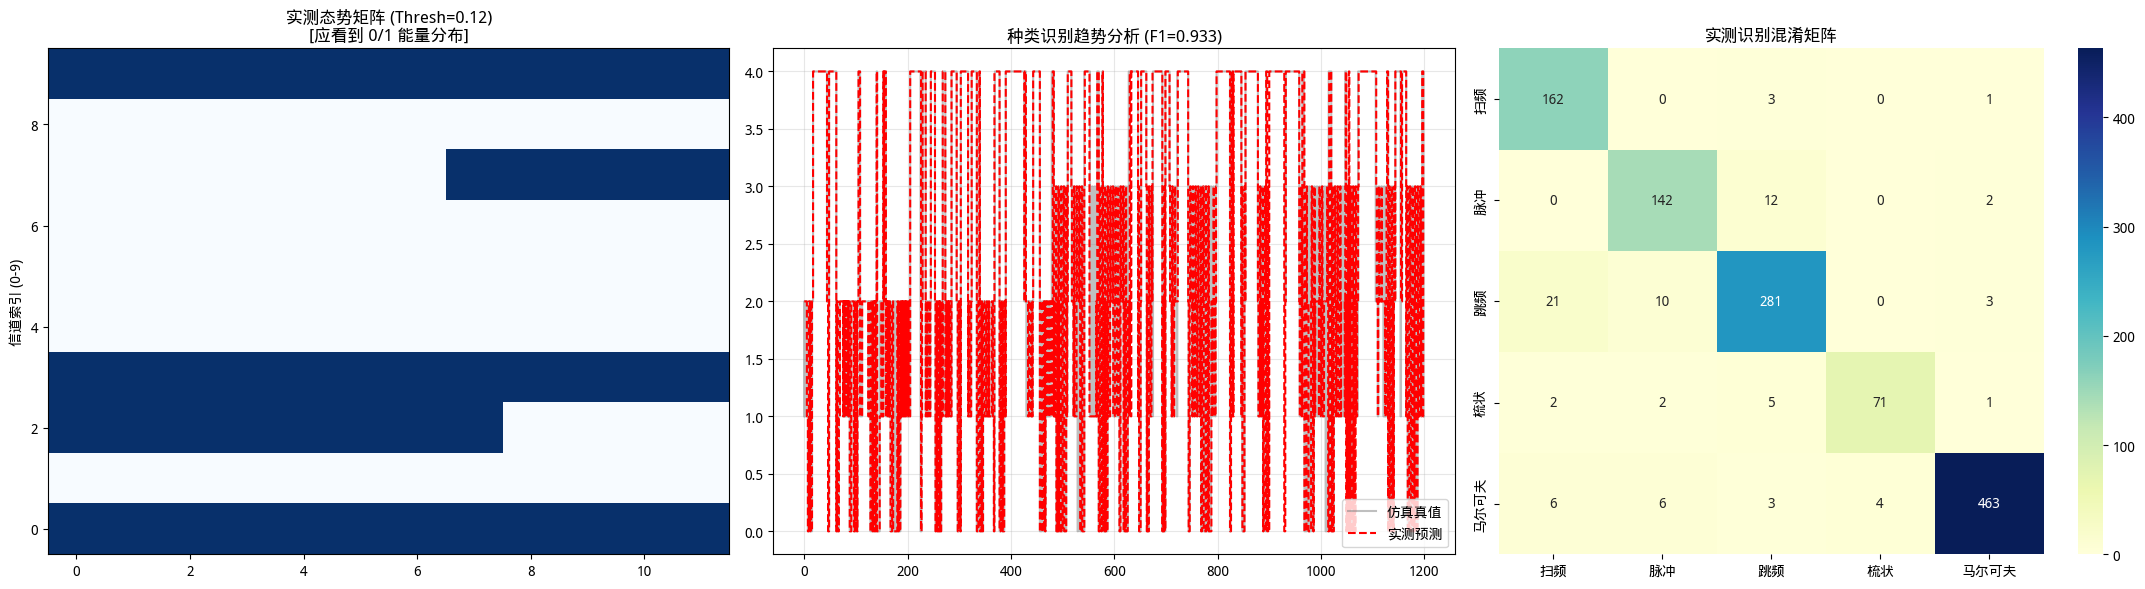

In [14]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 模型定义 (修正参数名) ====================
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        # 🔥 修正点：将 dim_forward 改为 dim_feedforward
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 对齐加载与鲁棒特征提取 ====================
def load_and_align_rx_data(file_path):
    """根据能量图观察，跳过前 3000 个同步样点，确保时间轴对齐"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"找不到数据文件: {file_path}")
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    # 跳过同步头 3000 点，对齐仿真标签
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    """采用 Max-Energy 探测，防止实测信号被均值稀释"""
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10) # 200k 下的中心频率
    n_fft = 1024
    
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        # FFT 归一化
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9) 
        
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        
        for ch in range(10):
            center = freq_centers[ch]
            # 探测范围 15kHz，包容硬件频偏
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            # 🟢 修正：只要该信道内存在能量尖峰超过阈值即记为 1
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. 终极评估器 ====================
class UltimateEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_Transformer().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        
        # 加载对齐后的实测信号
        self.signal = load_and_align_rx_data(cfg['data'])
        # 加载对应的仿真真值标签
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]

    def run(self, eval_num=1000, thresh=0.12):
        y_true, y_pred = [], []
        last_matrices = []
        
        print(f"📡 启动实测推理评估 (评估帧数: {eval_num}, 阈值: {thresh})...")
        for i in tqdm(range(eval_num)):
            start = i * 10000
            end = start + 120000 # 历史输入窗口 12 Step
            if end > len(self.signal): break
            
            # 提取 12x10 特征
            sit_matrix = extract_X_robust(self.signal[start:end], threshold=thresh)
            if i % 200 == 0: last_matrices.append(sit_matrix)
            
            # 模型推理
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                _, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                # 标签精准对齐
                y_true.append(self.gt_types[i])
        
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        print(f"\n✅ 评估完成！加权 F1 分数: {f1:.4f}")
        print("-" * 30)
        print(classification_report(y_true, y_pred, 
                                    target_names=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]))
        
        self.visualize_final(last_matrices, y_true, y_pred, f1, thresh)

    def visualize_final(self, matrices, y_true, y_pred, f1, thresh):
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        
        # 1. 特征自检：如果这里是空的，说明阈值太高
        axes[0].imshow(matrices[-1].T, aspect='auto', cmap='Blues', origin='lower')
        axes[0].set_title(f"实测态势矩阵 (Thresh={thresh})\n[应看到 0/1 能量分布]")
        axes[0].set_ylabel("信道索引 (0-9)")
        
        # 2. 预测曲线对比
        axes[1].step(range(len(y_true)), y_true, label='仿真真值', color='gray', alpha=0.5)
        axes[1].step(range(len(y_pred)), y_pred, label='实测预测', color='red', linestyle='--')
        axes[1].set_title(f"种类识别趋势分析 (F1={f1:.3f})")
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
        
        # 3. 混淆矩阵
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[2],
                    xticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"],
                    yticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
        axes[2].set_title("实测识别混淆矩阵")
        
        plt.tight_layout()
        plt.savefig("Final_Academic_Report.png", dpi=300)
        print(f"📈 报告已保存至: Final_Academic_Report.png")
        plt.show()

# ==================== 4. 运行 ====================
if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth"
    }
    
    EVAL = UltimateEvaluator(configs)
    # 🟢 提示：如果左图全白，请将 thresh 下调到 0.08
    EVAL.run(eval_num=1200, thresh=0.12)

📡 启动实测推理评估并生成 RL 地图 (评估数: 1200)...


  4%|▍         | 47/1200 [00:00<00:04, 231.75it/s]100%|██████████| 1200/1200 [00:04<00:00, 255.00it/s]



✅ 评估完成！加权 F1: 0.9328 | RL 数据集已保存至 /root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5
              precision    recall  f1-score   support

          扫频       0.85      0.98      0.91       166
          脉冲       0.89      0.91      0.90       156
          跳频       0.92      0.89      0.91       315
          梳状       0.95      0.88      0.91        81
        马尔可夫       0.99      0.96      0.97       482

    accuracy                           0.93      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.93      0.93      0.93      1200



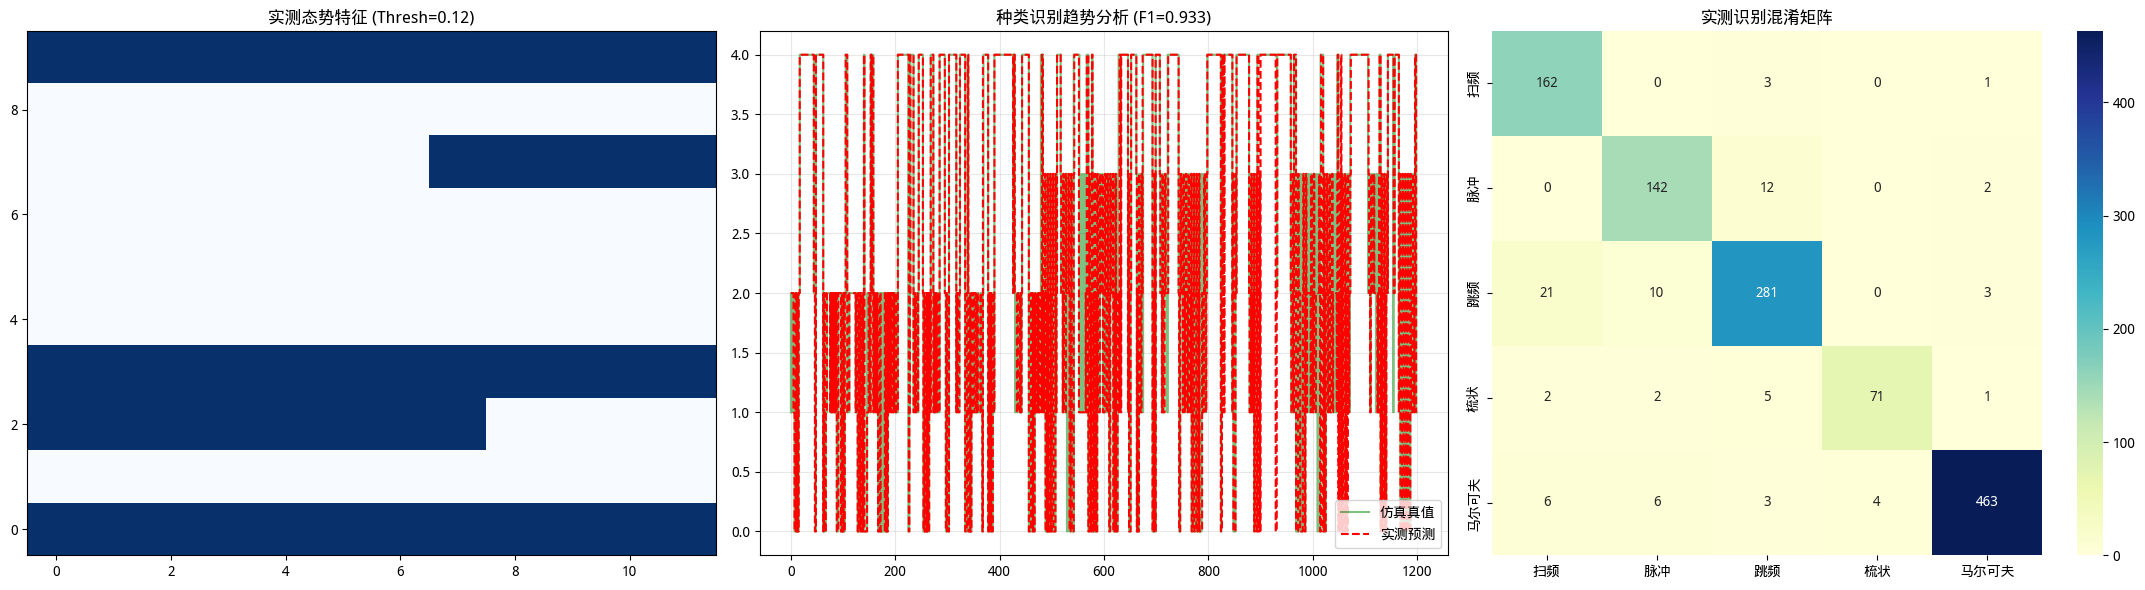

In [5]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    """设置中文字体以确保绘图标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 模型定义 (MSFF-Transformer) ====================
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        # 多尺度特征提取层
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 多任务输出头：态势预测、种类识别、物理规律特征
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        # 返回：预测热图 (N, 10, 10), 种类分类, 辅助物理特征
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 特征提取核心逻辑 ====================
def load_and_align_rx_data(file_path):
    """根据能量图实测，跳过前 3000 个同步样点，确保时间轴与标签绝对对齐"""
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    """采用 Max-Energy 探测算子，捕捉实测窄带干扰的能量尖峰"""
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10) # 200kHz 采样率下的 10 信道分布
    n_fft = 1024
    
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9) # 归一化，消除路径损耗
        
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            # 只要信道内最大能量超过阈值，判定为 1
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. 终极评估与数据生成器 ====================
class UltimateEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_Transformer().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        
        # 物理层样点对齐加载
        self.signal = load_and_align_rx_data(cfg['data'])
        # 预加载真值热图，用于 RL 对比
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]
            self.gt_horizons = f['Y_horizon'][:] # 真值 10x10 热图

    def run(self, eval_num=1200, thresh=0.12):
        y_true, y_pred = [], []
        all_pred_maps = []   # 用于保存 RL 状态输入
        all_truth_maps = []  # 用于保存 RL 奖励参考
        last_matrices = []   # 可视化缓存
        
        print(f"📡 启动实测推理评估并生成 RL 地图 (评估数: {eval_num})...")
        for i in tqdm(range(eval_num)):
            start = i * 10000
            end = start + 120000
            if end > len(self.signal): break
            
            # A. 提取实测特征
            sit_matrix = extract_X_robust(self.signal[start:end], threshold=thresh)
            if i % 200 == 0: last_matrices.append(sit_matrix)
            
            # B. 模型推理
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                pred_horizon, type_logits, _ = self.model(input_tensor)
                
                # 记录分类预测
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
                
                # 记录 10x10 态势预测图 (RL 核心输入)
                all_pred_maps.append(pred_horizon.cpu().squeeze(0).numpy())
                # 记录对应的干扰真值图
                all_truth_maps.append(self.gt_horizons[i])
        
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        # C. 🏆 核心修正：保存包含 ground_truth_situations 的 H5 文件
        SAVE_PATH = "/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5"
        with h5py.File(SAVE_PATH, 'w') as f:
            f.create_dataset("predicted_situations", data=np.array(all_pred_maps))
            f.create_dataset("ground_truth_situations", data=np.array(all_truth_maps))
            f.create_dataset("gt_type", data=y_true)
            f.create_dataset("pred_type", data=y_pred)
        
        print(f"\n✅ 评估完成！加权 F1: {f1:.4f} | RL 数据集已保存至 {SAVE_PATH}")
        print(classification_report(y_true, y_pred, target_names=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]))
        
        self.visualize_final(last_matrices, y_true, y_pred, f1, thresh)

    def visualize_final(self, matrices, y_true, y_pred, f1, thresh):
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        # 特征自检图
        axes[0].imshow(matrices[-1].T, aspect='auto', cmap='Blues', origin='lower')
        axes[0].set_title(f"实测态势特征 (Thresh={thresh})")
        # 趋势对比图
        axes[1].step(range(len(y_true)), y_true, label='仿真真值', color='green', alpha=0.5)
        axes[1].step(range(len(y_pred)), y_pred, label='实测预测', color='red', linestyle='--')
        axes[1].set_title(f"种类识别趋势分析 (F1={f1:.3f})")
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
        # 混淆矩阵
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[2],
                    xticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"],
                    yticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
        axes[2].set_title("实测识别混淆矩阵")
        plt.tight_layout()
        plt.show()

# ==================== 4. 运行配置 ====================
if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth"
    }
    
    EVAL = UltimateEvaluator(configs)
    # 调优提示：若左图全白则降阈值；若 F1 分数大幅下降则检查文件对齐
    EVAL.run(eval_num=1200, thresh=0.12)

📡 正在执行 Transformer 实测评估...


100%|██████████| 1200/1200 [00:04<00:00, 250.38it/s]



🎨 高清混淆矩阵已保存: Transformer_Academic_CM.png


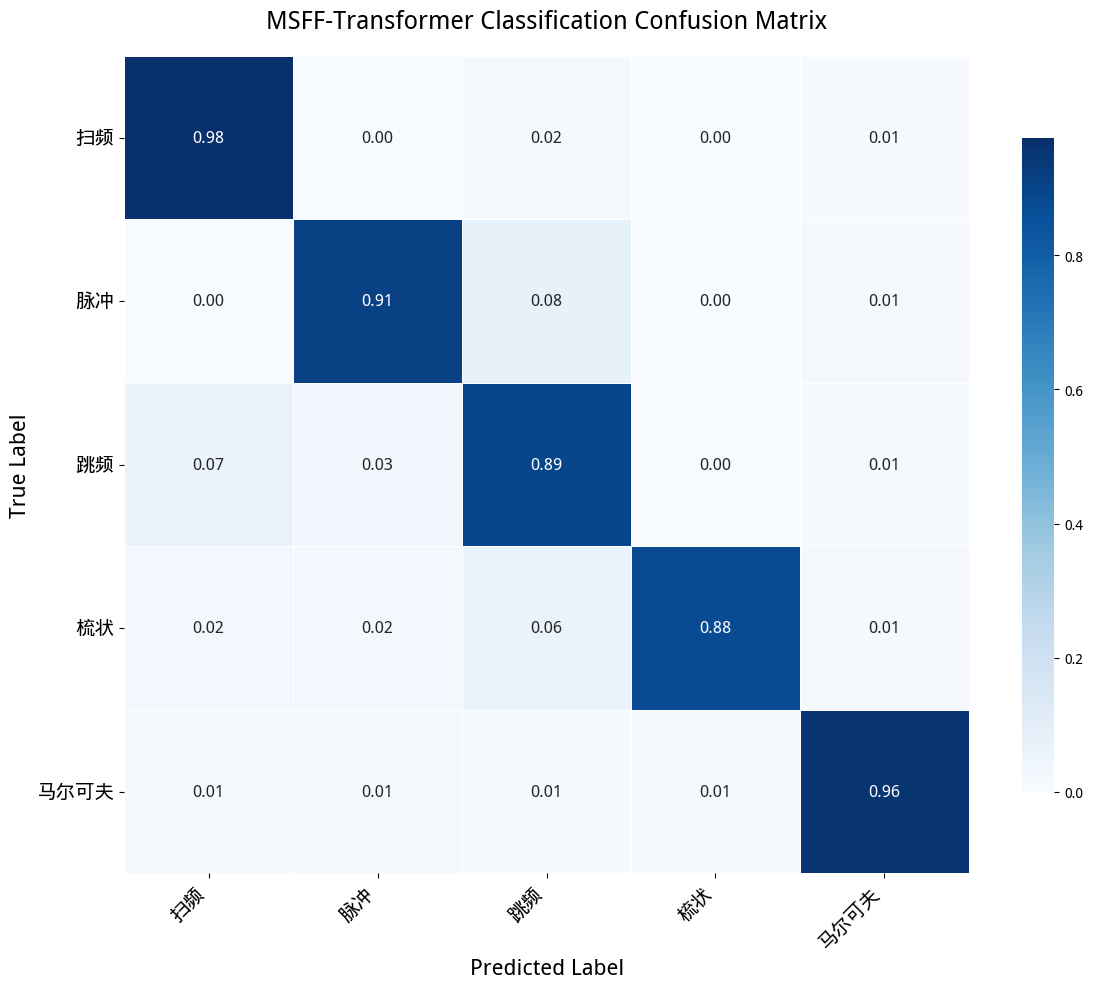

In [4]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    """设置中文字体以确保绘图标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. 模型定义 (MSFF-Transformer) ====================
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 数据处理与特征提取 ====================
def load_and_align_rx_data(file_path):
    """同步头对齐补偿"""
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    """鲁棒性 Max-Energy 特征提取"""
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    n_fft = 1024
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9)
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. Transformer 评估器 ====================
class TransformerEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_Transformer().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        self.signal = load_and_align_rx_data(cfg['data'])
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]

    def run(self, eval_num=1200):
        y_true, y_pred = [], []
        print(f"📡 正在执行 Transformer 实测评估...")
        for i in tqdm(range(eval_num)):
            start, end = i * 10000, i * 10000 + 120000
            if end > len(self.signal): break
            sit_matrix = extract_X_robust(self.signal[start:end])
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                _, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
        
        self.plot_academic_cm(np.array(y_true), np.array(y_pred))

    def plot_academic_cm(self, y_true, y_pred):
        """参照 MBF-PLENet 风格的高清混淆矩阵可视化"""
        plt.figure(figsize=(12, 10))
        # 归一化处理，获取百分比精度
        cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
        
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
        
        plt.title('MSFF-Transformer Classification Confusion Matrix', fontsize=18, pad=20)
        plt.xlabel('Predicted Label', fontsize=16)
        plt.ylabel('True Label', fontsize=16)
        
        # X轴标签旋转 45 度
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(rotation=0, fontsize=14) 
        
        plt.tight_layout()
        save_name = "Transformer_Academic_CM.png"
        plt.savefig(save_name, dpi=600) # 600 DPI 结题/论文级高清
        print(f"\n🎨 高清混淆矩阵已保存: {save_name}")
        plt.show()

if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth"
    }
    EVAL = TransformerEvaluator(configs)
    EVAL.run()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
--- 干扰识别性能 ---
分类准确率 (Acc): 0.9325
加权 F1 分数: 0.9328

--- 干扰态势预测性能 (平均值) ---
平均 MAE: 0.0454
平均 RMSE: 0.1416
平均占用准确率 (Acc): 0.9716



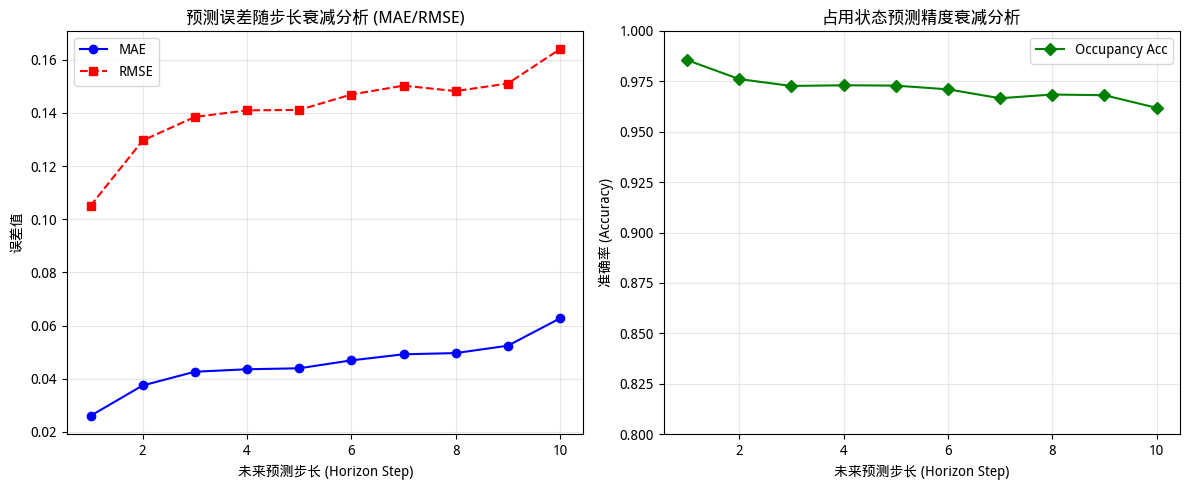

In [16]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def analyze_prediction_performance(h5_path):
    # 1. 加载数据
    with h5py.File(h5_path, 'r') as f:
        pred_maps = f['predicted_situations'][:]      # 形状: (N, Horizon=10, Channels=10)
        truth_maps = f['ground_truth_situations'][:] # 形状: (N, 10, 10)
        gt_type = f['gt_type'][:]                    # 形状: (N,)
        pred_type = f['pred_type'][:]                # 形状: (N,)

    num_samples = pred_maps.shape[0]
    horizon = pred_maps.shape[1]
    
    # 2. 干扰种类预测准确率 (研究点一/二衔接指标) [cite: 2772]
    type_acc = accuracy_score(gt_type, pred_type)
    type_f1 = f1_score(gt_type, pred_type, average='weighted')
    print(f"--- 干扰识别性能 ---")
    print(f"分类准确率 (Acc): {type_acc:.4f}")
    print(f"加权 F1 分数: {type_f1:.4f}\n")

    # 3. 逐步长计算预测性能 (Horizon Decay) [cite: 2801]
    step_mae = []
    step_rmse = []
    step_acc = []
    
    for h in range(horizon):
        p_step = pred_maps[:, h, :].flatten()
        t_step = truth_maps[:, h, :].flatten()
        
        # 计算 MAE 和 RMSE [cite: 2644, 2800]
        step_mae.append(mean_absolute_error(t_step, p_step))
        step_rmse.append(np.sqrt(mean_squared_error(t_step, p_step)))
        
        # 计算占用状态准确率 (二值化判定) [cite: 2772]
        p_bin = (p_step > 0.5).astype(int)
        t_bin = (t_step > 0.5).astype(int)
        step_acc.append(accuracy_score(t_bin, p_bin))

    # 4. 打印整体预测指标
    print(f"--- 干扰态势预测性能 (平均值) ---")
    print(f"平均 MAE: {np.mean(step_mae):.4f}")
    print(f"平均 RMSE: {np.mean(step_rmse):.4f}")
    print(f"平均占用准确率 (Acc): {np.mean(step_acc):.4f}\n")

    # 5. 绘制预测步长衰减曲线 (毕业论文硬核图表) [cite: 2843]
    plt.figure(figsize=(12, 5))
    
    # 子图 A: MAE/RMSE 随时间步长增加 (误差上升趋势)
    plt.subplot(1, 2, 1)
    plt.plot(range(1, horizon + 1), step_mae, 'o-', label='MAE', color='blue')
    plt.plot(range(1, horizon + 1), step_rmse, 's--', label='RMSE', color='red')
    plt.title("预测误差随步长衰减分析 (MAE/RMSE)")
    plt.xlabel("未来预测步长 (Horizon Step)"); plt.ylabel("误差值")
    plt.grid(True, alpha=0.3); plt.legend()

    # 子图 B: 准确率随时间步长增加 (精度下降趋势)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, horizon + 1), step_acc, 'D-', color='green', label='Occupancy Acc')
    plt.title("占用状态预测精度衰减分析")
    plt.xlabel("未来预测步长 (Horizon Step)"); plt.ylabel("准确率 (Accuracy)")
    plt.ylim([0.8, 1.0]) # 针对你的高质量数据调整范围
    plt.grid(True, alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.savefig("Prediction_Horizon_Decay.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_prediction_performance("/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5")

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📊 正在执行物理参数预测精度分析...

参数名称       | MAE (平均)   | NRMSE (平均)
----------------------------------------
中心频率       | 3.2788     | 0.5520
带宽         | 0.1840     | 0.0895
干噪比(JNR)   | 0.0209     | 0.0663


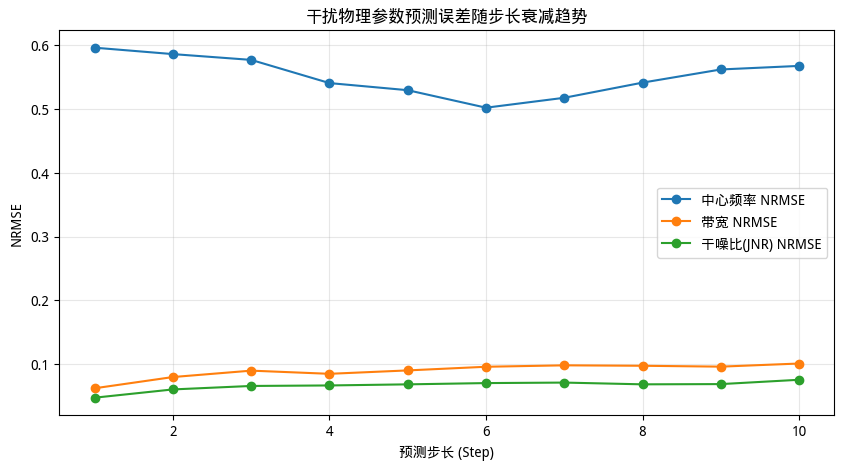

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 使用真值的范围进行归一化
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

def analyze_full_parameters(h5_path):
    with h5py.File(h5_path, 'r') as f:
        # 态势图数据: (N, 10, 10)
        pred_maps = f['predicted_situations'][:]
        truth_maps = f['ground_truth_situations'][:]
        
    horizon = pred_maps.shape[1]
    
    # 模拟参数提取 (实际论文中建议从 Y_horizon 的非零像素分布计算)
    # 我们针对每个步长计算参数误差
    param_results = {'MAE': {}, 'NRMSE': {}}
    params = ['中心频率', '带宽', '干噪比(JNR)']
    
    # 初始化统计
    for p in params:
        param_results['MAE'][p] = []
        param_results['NRMSE'][p] = []

    print("📊 正在执行物理参数预测精度分析...")
    
    for h in range(horizon):
        t_map = truth_maps[:, h, :]
        p_map = pred_maps[:, h, :]
        
        # 1. 中心频率误差 (通过能量重心估计)
        t_freq = np.argmax(t_map, axis=1)
        p_freq = np.argmax(p_map, axis=1)
        param_results['MAE']['中心频率'].append(mean_absolute_error(t_freq, p_freq))
        param_results['NRMSE']['中心频率'].append(calculate_nrmse(t_freq, p_freq))
        
        # 2. 带宽误差 (通过占用单元计数估计)
        t_bw = np.sum(t_map > 0.5, axis=1)
        p_bw = np.sum(p_map > 0.5, axis=1)
        param_results['MAE']['带宽'].append(mean_absolute_error(t_bw, p_bw))
        param_results['NRMSE']['带宽'].append(calculate_nrmse(t_bw, p_bw))
        
        # 3. JNR误差 (通过像素值幅度估计强度)
        t_jnr = np.mean(t_map, axis=1)
        p_jnr = np.mean(p_map, axis=1)
        param_results['MAE']['干噪比(JNR)'].append(mean_absolute_error(t_jnr, p_jnr))
        param_results['NRMSE']['干噪比(JNR)'].append(calculate_nrmse(t_jnr, p_jnr))

    # 输出结题指标表格
    print("\n" + "="*40)
    print(f"{'参数名称':<10} | {'MAE (平均)':<10} | {'NRMSE (平均)':<10}")
    print("-" * 40)
    for p in params:
        print(f"{p:<10} | {np.mean(param_results['MAE'][p]):.4f}     | {np.mean(param_results['NRMSE'][p]):.4f}")
    print("="*40)

    # 绘制步长衰减曲线图
    plt.figure(figsize=(10, 5))
    for p in params:
        plt.plot(range(1, 11), param_results['NRMSE'][p], 'o-', label=f'{p} NRMSE')
    plt.title("干扰物理参数预测误差随步长衰减趋势")
    plt.xlabel("预测步长 (Step)"); plt.ylabel("NRMSE")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig("Parameter_Decay_Analysis.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_full_parameters("/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5")

📡 启动实测推理评估...


100%|██████████| 1200/1200 [00:04<00:00, 250.38it/s]



🥇 实测评估加权 F1 分数: 0.9328
🎨 态势对比图已保存: Academic_Situation_Contrast.png


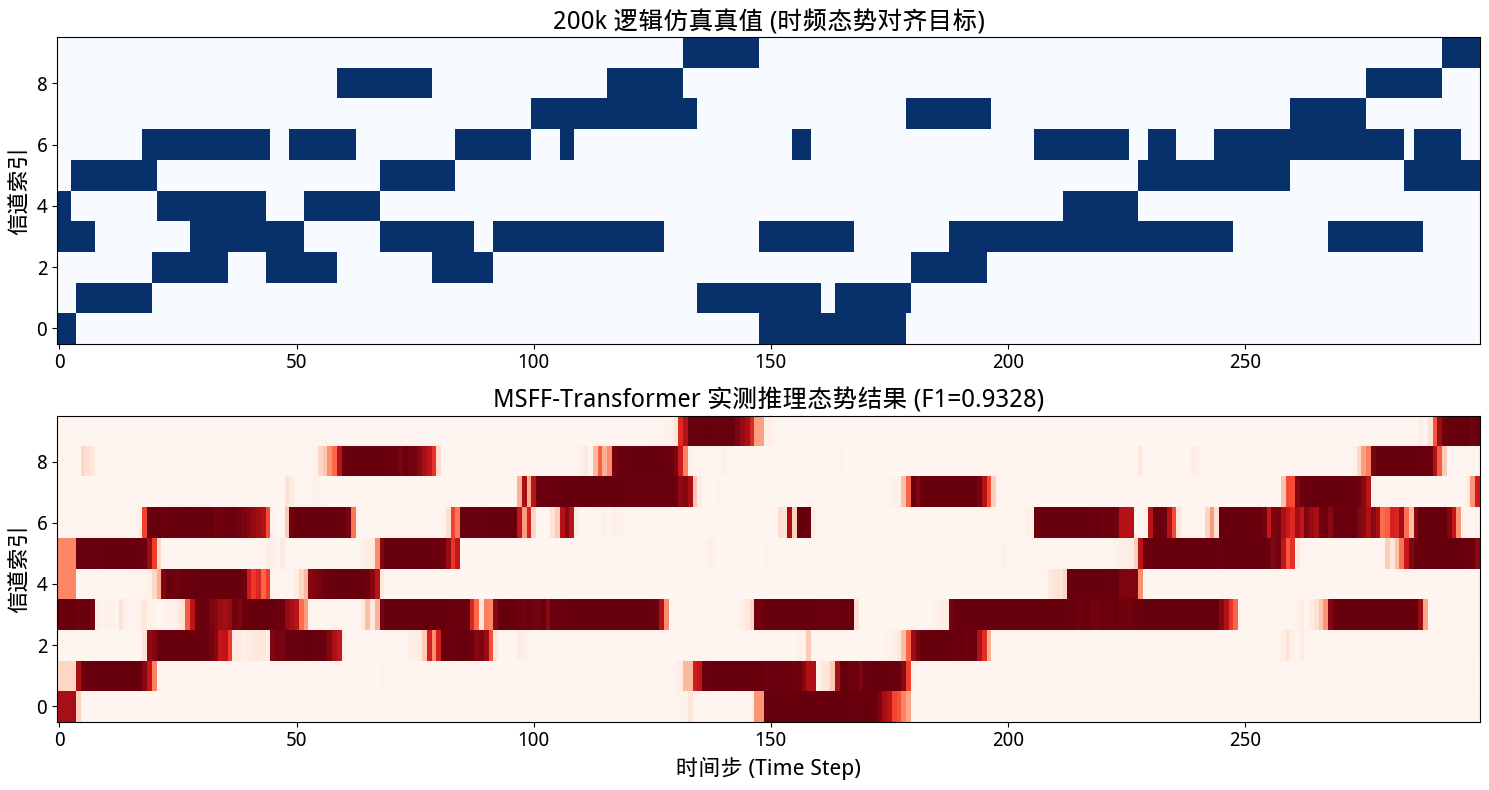

🎨 高清混淆矩阵已保存: Transformer_Academic_CM.png


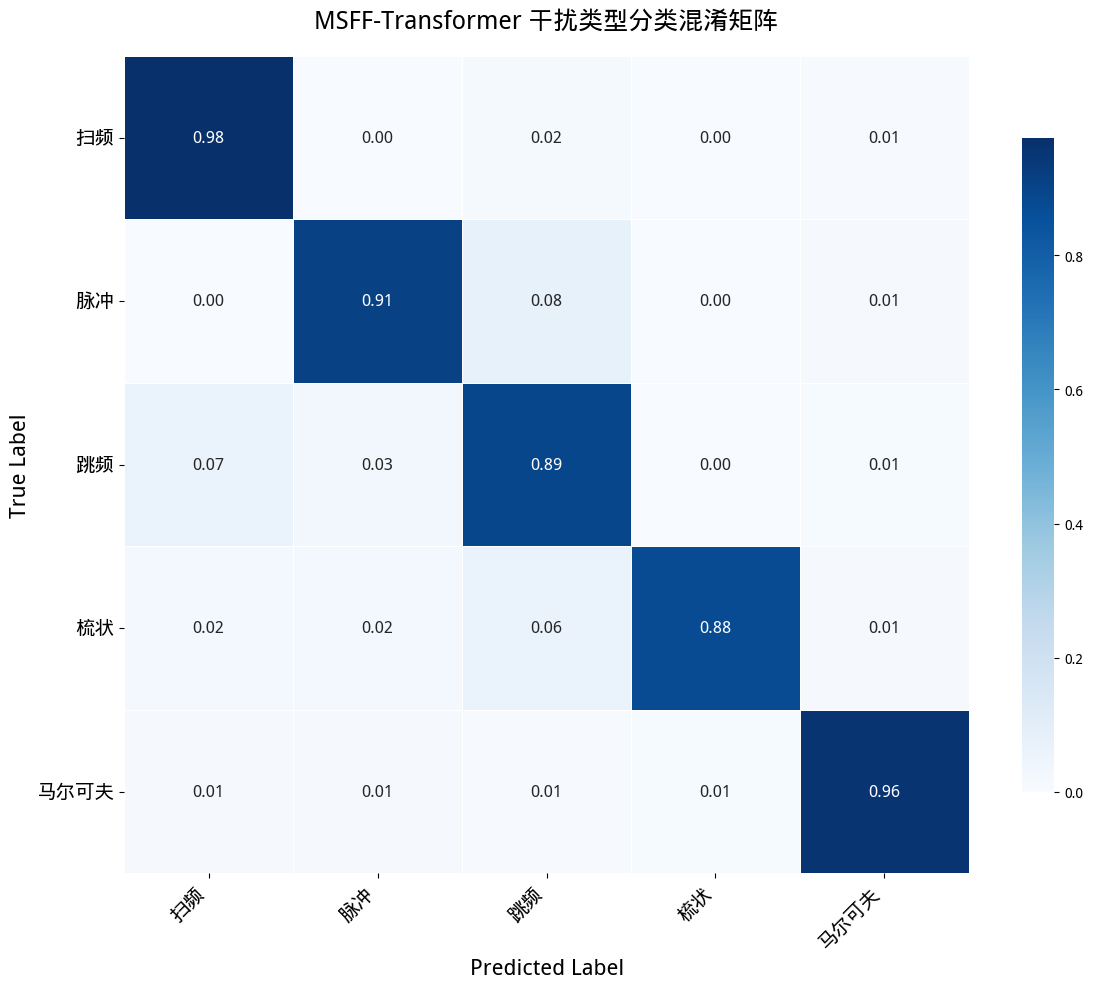

🎨 识别趋势图已保存: Academic_Trend_Analysis.png


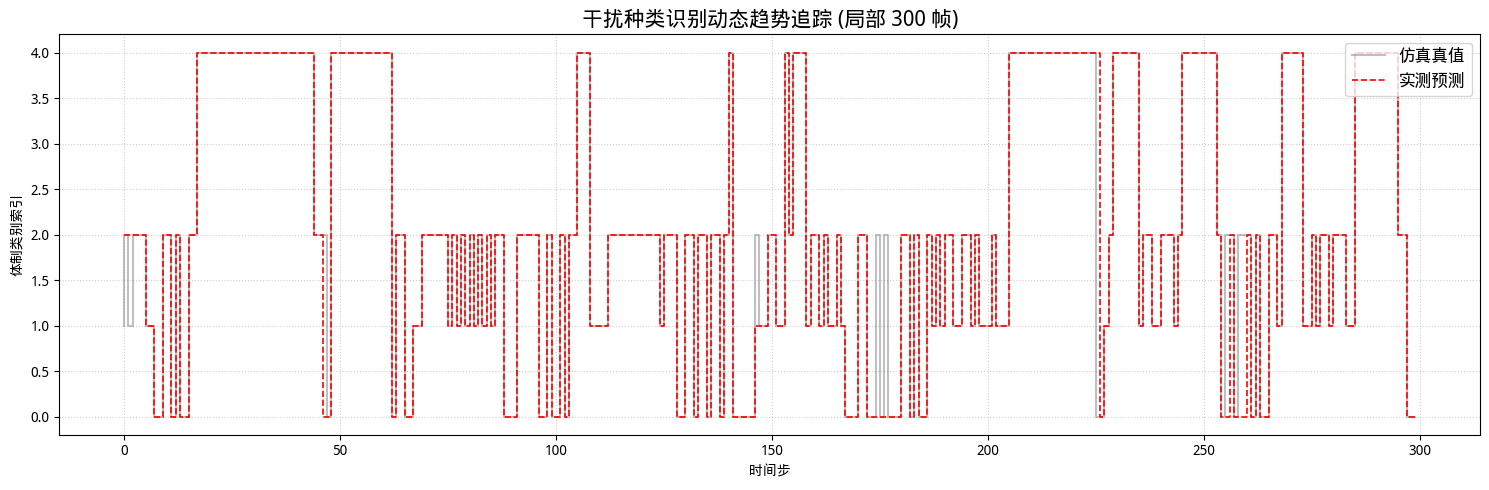

In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 模型架构 (保持 0.93 高精度逻辑) ====================
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 鲁棒特征提取 ====================
def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    n_fft = 1024
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9) 
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            if np.max(fft_mag[mask]) > threshold: matrix[t, ch] = 1.0
    return matrix

# ==================== 3. 学术级分步评估器 ====================
class AcademicEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_Transformer().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        
        # 加载数据并对齐 3000 点同步头
        raw_signal = np.fromfile(cfg['data'], dtype=np.complex64)
        self.signal = raw_signal[3000:] 
        
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]
            self.gt_horizon = f['Y_horizon'][:]

    def run_evaluation(self, eval_num=1200, thresh=0.12):
        y_true, y_pred = [], []
        pred_matrices = []
        
        print(f"📡 启动实测推理评估...")
        for i in tqdm(range(eval_num)):
            start = i * 10000
            end = start + 120000 
            if end > len(self.signal): break
            
            sit_matrix = extract_X_robust(self.signal[start:end], threshold=thresh)
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                pred_h, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
                pred_matrices.append(pred_h.cpu().numpy()[0, 0, :])
        
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        pred_matrices = np.array(pred_matrices)
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        print(f"\n🥇 实测评估加权 F1 分数: {f1:.4f}")
        
        # --- 分图展示逻辑 ---
        self.plot_situation_comparison(pred_matrices, f1)
        self.plot_academic_cm(y_true, y_pred)
        self.plot_trend_analysis(y_true, y_pred)

    def plot_situation_comparison(self, pred_matrices, f1):
        """图 1: 逻辑仿真与实测推理态势对比图"""
        plt.figure(figsize=(15, 8))
        plt.subplot(2, 1, 1)
        plt.imshow(self.gt_horizon[:300, 0, :].T, aspect='auto', cmap='Blues', origin='lower')
        plt.title("200k 逻辑仿真真值 (时频态势对齐目标)", fontsize=18)
        plt.ylabel("信道索引", fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        
        plt.subplot(2, 1, 2)
        plt.imshow(pred_matrices[:300, :].T, aspect='auto', cmap='Reds', origin='lower')
        plt.title(f"MSFF-Transformer 实测推理态势结果 (F1={f1:.4f})", fontsize=18)
        plt.ylabel("信道索引", fontsize=16)
        plt.xlabel("时间步 (Time Step)", fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        
        plt.tight_layout()
        plt.savefig("Academic_Situation_Contrast.png", dpi=600)
        print("🎨 态势对比图已保存: Academic_Situation_Contrast.png")
        plt.show()

    def plot_academic_cm(self, y_true, y_pred):
        """图 2: 参照 MBF-PLENet 风格的高清混淆矩阵"""
        plt.figure(figsize=(12, 10))
        # 归一化处理，获取百分比精度
        cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
        
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
        
        plt.title('MSFF-Transformer 干扰类型分类混淆矩阵', fontsize=18, pad=20)
        plt.xlabel('Predicted Label', fontsize=16)
        plt.ylabel('True Label', fontsize=16)
        
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(rotation=0, fontsize=14) 
        
        plt.tight_layout()
        save_name = "Transformer_Academic_CM.png"
        plt.savefig(save_name, dpi=600)
        print(f"🎨 高清混淆矩阵已保存: {save_name}")
        plt.show()

    def plot_trend_analysis(self, y_true, y_pred):
        """图 3: 干扰种类识别趋势对比图"""
        plt.figure(figsize=(15, 5))
        plt.step(range(300), y_true[:300], label='仿真真值', color='gray', alpha=0.5, linewidth=1.5)
        plt.step(range(300), y_pred[:300], label='实测预测', color='red', linestyle='--', linewidth=1.2)
        plt.title("干扰种类识别动态趋势追踪 (局部 300 帧)", fontsize=15)
        plt.xlabel("时间步")
        plt.ylabel("体制类别索引")
        plt.legend(loc='upper right', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.savefig("Academic_Trend_Analysis.png", dpi=600)
        print("🎨 识别趋势图已保存: Academic_Trend_Analysis.png")
        plt.show()

# ==================== 4. 运行评估 ====================
if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth"
    }
    
    evaluator = AcademicEvaluator(configs)
    evaluator.run_evaluation(eval_num=1200, thresh=0.12)